In [21]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

### Presentation of the data:

**The Primary Anchor (1 asset)**: 

- rough rice futures (source: Investing.com)

**The Sector Proxies (2–4 assets): Relevant ETFs to capture broader sector beta**
- Invesco DB Agriculture Fund, DBA (yfinance)
- iPath Bloomberg Grains ETN, JJG (yfinance)
- Elements Rogers International Agriculture ETN, RJA (yfinance)
- WisdomTree Grains ETF, 1688.T (yfinance)

**The Individual Universe (10–15 assets): companies
directly involved in the commodity’s value chain**


- KRBL Limited, KRBL.NS (yfinance) – Indian company specializing in basmati rice production and export
- LT Foods Limited, LTFOODS.NS (yfinance) – Indian rice producer and owner of the Daawat basmati brand
- Chaman Lal Setia Exports Ltd, CLSEL.NS (yfinance) – Indian exporter of basmati rice
- Kohinoor Foods Ltd, KOHINOOR.NS (yfinance) – Indian basmati rice producer and exporter
- Archer Daniels Midland Company, ADM (yfinance) – Global agribusiness and grain trading company
- Bunge Global SA, BG (yfinance) – Multinational agribusiness and food company specializing in grain trading
- Olam Group Ltd, VC2.SI (yfinance) – Singapore-based agricultural commodity trader involved in rice and other crops
- Village Farms International Inc, VFF (yfinance) – Agricultural producer focused on controlled-environment farming
- Nutrien Ltd, NTR (yfinance) – Canadian agricultural input company and fertilizer producer supporting global crop production
- Mosaic Company, MOS (yfinance) – Major producer of phosphate and potash fertilizers used in agriculture
- CF Industries Holdings Inc, CF (yfinance) – Global manufacturer of nitrogen fertilizers for crop production
- Adecoagro SA, AGRO (yfinance) – Agricultural production company operating farms and food processing in South America
- Fresh Del Monte Produce Inc, FDP (yfinance) – Global agricultural company involved in food production and distribution


In [22]:
anchor  = pd.read_csv("futures_rice.csv")

sector_proxies = [
    "DBA",     
    "JJG",     
    "RJA",     
    "1688.T"   
]

companies = [
    "KRBL.NS",
    "LTFOODS.NS",
    "CLSEL.NS",
    "KOHINOOR.NS",
    "ADM",
    "BG",
    "VC2.SI",
    "VFF",
    "NTR",
    "MOS",
    "CF",
    "AGRO",
    "FDP"
]



In [23]:
tickers = sector_proxies + companies


data = yf.download(tickers, start="2018-01-01", progress=False)

close_prices = data["Close"]

print(close_prices.head())

Ticker      1688.T        ADM      AGRO         BG         CF  CLSEL.NS  \
Date                                                                      
2018-01-01   395.0        NaN       NaN        NaN        NaN       NaN   
2018-01-02   395.0  31.407623  9.198832  52.966431  35.073055       NaN   
2018-01-03   395.0  31.164753  9.394551  54.103802  35.081177       NaN   
2018-01-04   399.0  31.689667  9.350070  54.898434  35.447029       NaN   
2018-01-05   390.0  31.478130  9.207728  54.485531  35.503937       NaN   

Ticker            DBA        FDP  JJG  KOHINOOR.NS     KRBL.NS  LTFOODS.NS  \
Date                                                                         
2018-01-01        NaN        NaN  NaN    74.900002  556.974548         NaN   
2018-01-02  16.306484  39.298065  NaN    73.599998  555.493774         NaN   
2018-01-03  16.297888  39.524155  NaN    75.900002  560.167664         NaN   
2018-01-04  16.272099  40.353149  NaN    79.949997  566.276062         NaN   
2018-0

In [24]:
anchor["Date"] = pd.to_datetime(anchor["Date"], dayfirst=True)
anchor["Dernier"] = anchor["Dernier"].str.replace(",", ".").astype(float)
anchor = anchor.set_index("Date")

anchor_close = anchor["Dernier"].rename("Futures")

close_prices = close_prices.join(anchor_close)

In [25]:
close_prices

,1688.T,ADM,AGRO,BG,CF,CLSEL.NS,DBA,FDP,JJG,KOHINOOR.NS,KRBL.NS,LTFOODS.NS,MOS,NTR,RJA,VC2.SI,VFF,Futures
Date,,,,,,,,,,,,,,,,,,
2018-01-01,395.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,74.900002,556.974548,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2018-01-02,395.000000,31.407623,9.198832,52.966431,35.073055,NaN,16.306484,39.298065,NaN,73.599998,555.493774,NaN,23.434713,41.927883,6.06,1.330321,NaN,NaN
2018-01-03,395.000000,31.164753,9.394551,54.103802,35.081177,NaN,16.297888,39.524155,NaN,75.900002,560.167664,NaN,23.223673,42.395027,6.08,1.310757,NaN,NaN
2018-01-04,399.000000,31.689667,9.350070,54.898434,35.447029,NaN,16.272099,40.353149,NaN,79.949997,566.276062,NaN,23.584198,42.540524,6.08,1.330321,NaN,NaN
2018-01-05,390.000000,31.478130,9.207728,54.485531,35.503937,NaN,16.186140,40.361530,NaN,88.250000,577.104492,NaN,23.619375,42.678371,6.04,1.330321,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-03-02,552.700012,69.610001,9.320000,120.610001,104.300003,260.000000,25.990000,42.716900,NaN,24.520000,330.500000,380.200012,27.510000,75.739998,NaN,0.875000,3.450,10.62
2026-03-03,548.000000,67.989998,9.130000,116.620003,106.300003,NaN,26.020000,42.280003,NaN,NaN,NaN,NaN,26.780001,74.419998,NaN,0.870000,3.340,10.59
2026-03-04,550.500000,67.220001,9.590000,115.010002,104.709999,247.699997,26.120001,42.660000,NaN,23.990000,320.500000,367.549988,26.010000,73.589996,NaN,0.840000,3.430,10.44


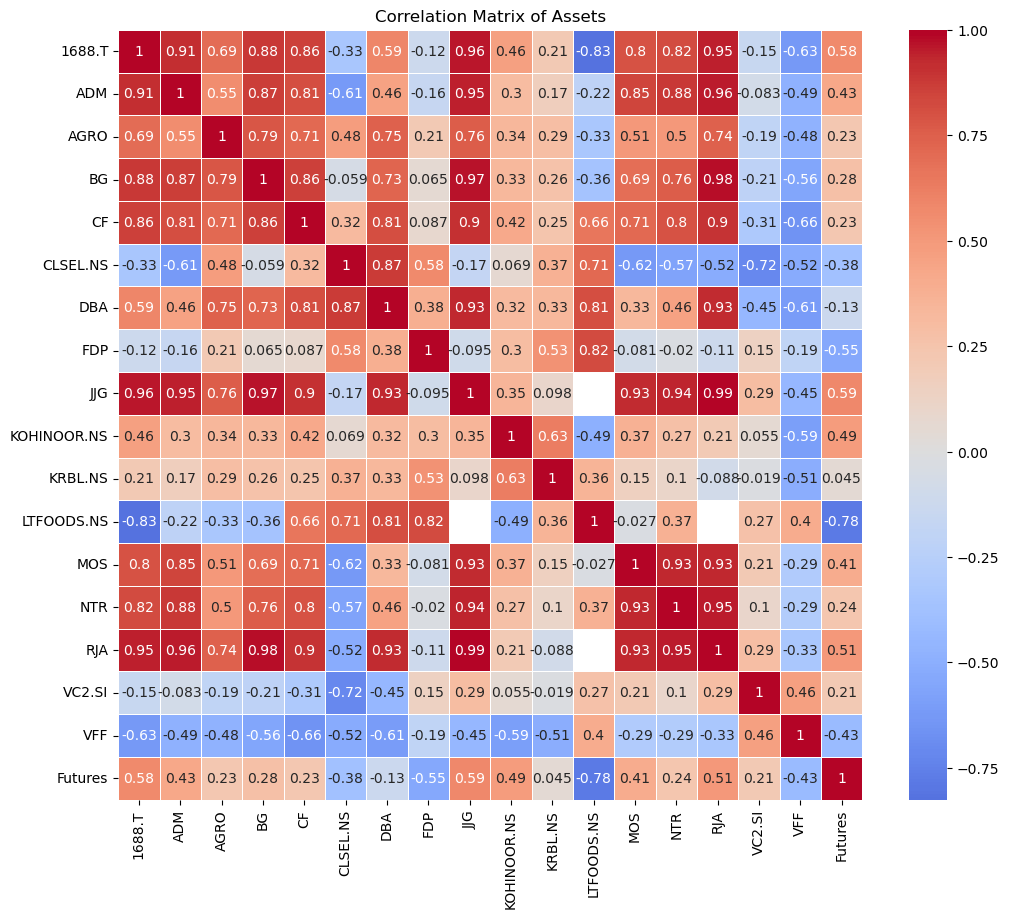

In [26]:
corr_matrix = close_prices.corr()

plt.figure(figsize=(12,10))

sns.heatmap(corr_matrix,
    annot=True,
    cmap="coolwarm",
    center=0,
    linewidths=0.5
)

plt.title("Correlation Matrix of Assets")
plt.show()